In [4]:
import os
import threading
import gempy as gp
import pandas as pd
import HelperMethods
import gempy_viewer as gpv
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# Loading in Data

In [36]:
# Setup base directory
BASE_DIR = os.getcwd()

# Define data directory and file paths
data_dir = os.path.join(BASE_DIR, '..', 'Data', 'Tharsis AOI 1')

path_to_data = os.path.join(data_dir, 'formationinputpoints_reduced.csv')
path_to_orientations = os.path.join(data_dir, 'orientations_reduced.csv')
points_df = pd.read_csv(path_to_data, encoding='latin1', engine='python')
orientations_df = pd.read_csv(path_to_orientations, encoding='latin1', engine='python')

# Model Parameters

In [37]:
# Define coordinate bounds from the data
top_right = (-678192, 4549947)
bottom_right = (-677518, 4529455)
bottom_left = (-706792, 4528453)
top_left = (-707522, 4548927)


# Calculate bounding box of the area of interest
min_x = min(top_left[0], bottom_left[0])
max_x = max(top_right[0], bottom_right[0])
min_y = min(bottom_left[1], bottom_right[1])
max_y = max(top_left[1], top_right[1])
max_z = points_df['Z'].max()

model_depth = -500  # Define the depth of the model

# 14. Geophysical data

1 voxel:

* 1 lithology: scalar
* 3 coordinates: floats
* 2 geophysical values: floats

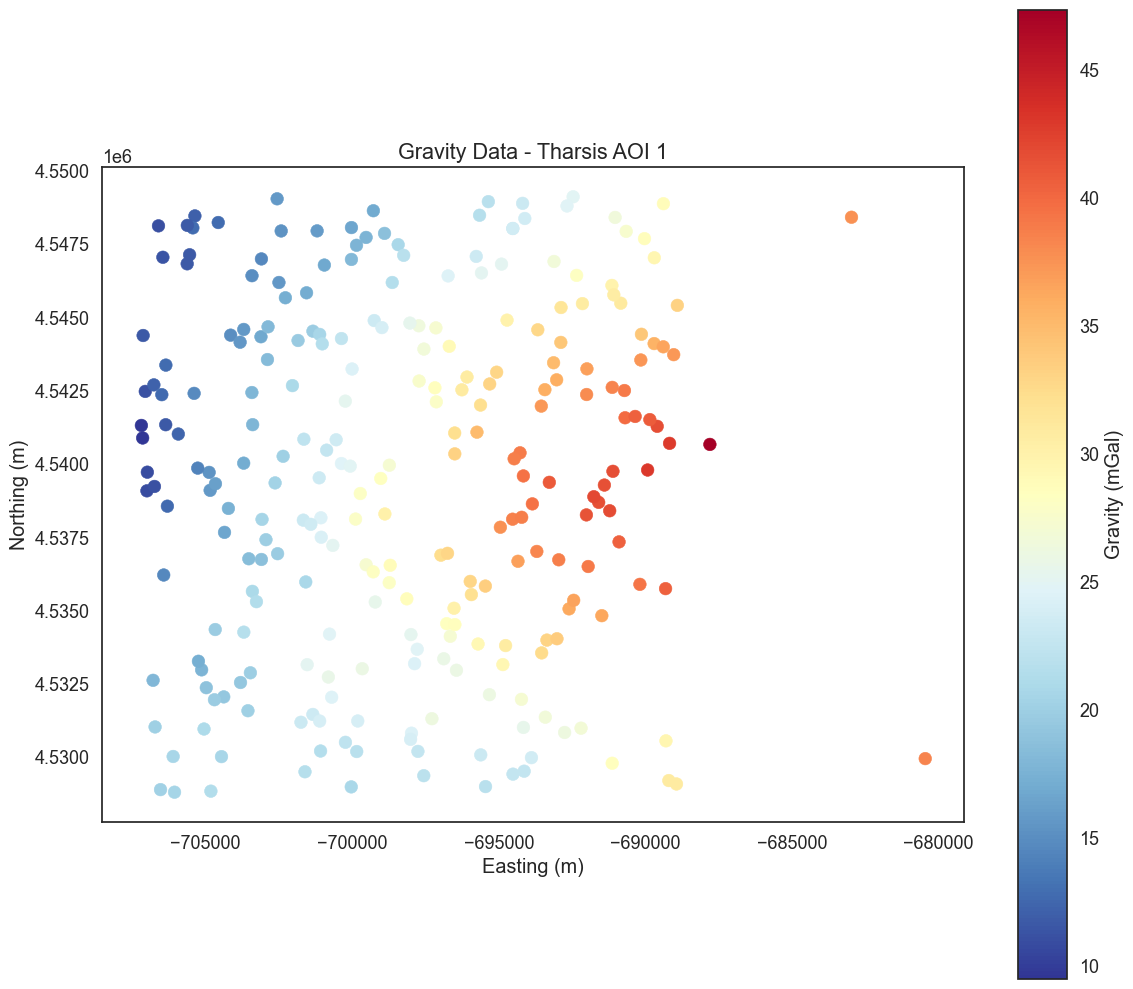

Gravity data loaded successfully!
Data shape: (260, 8)
Columns: ['ID', 'VALU_COORX', 'VALU_COORY', 'CODE_H50', 'CODE_DOCU', 'VALU_BOU267', 'ESRI_OID', 'geometry']
Gravity range: 9.51 to 47.32 mGal


In [54]:
# Load and plot the geophysical gravity data and convert to right coordinate system
gravity_data = gpd.read_file(r"C:\Users\mrcon\PycharmProjects\Mineye-Terranigma-1\Data\Tharsis AOI 1\AOI1_GF_Gravity_cropped_EPSG23030.geojson")
gravity_data = gravity_data.to_crs(epsg=3857)

gravity_data['VALU_COORX'] = gravity_data.geometry.x
gravity_data['VALU_COORY'] = gravity_data.geometry.y

# Clip data to model bounds
gravity_data = gravity_data.cx[min_x:max_x, min_y:max_y]

# Create a plot of the gravity data
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the gravity data with a colormap
gravity_plot = gravity_data.plot(
    column='VALU_BOU267', 
    ax=ax, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Gravity (mGal)', 'orientation': 'vertical'}
)

ax.set_title('Gravity Data - Tharsis AOI 1')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Gravity data loaded successfully!")
print(f"Data shape: {gravity_data.shape}")
print(f"Columns: {gravity_data.columns.tolist()}")
print(f"Gravity range: {gravity_data['VALU_BOU267'].min():.2f} to {gravity_data['VALU_BOU267'].max():.2f} mGal")

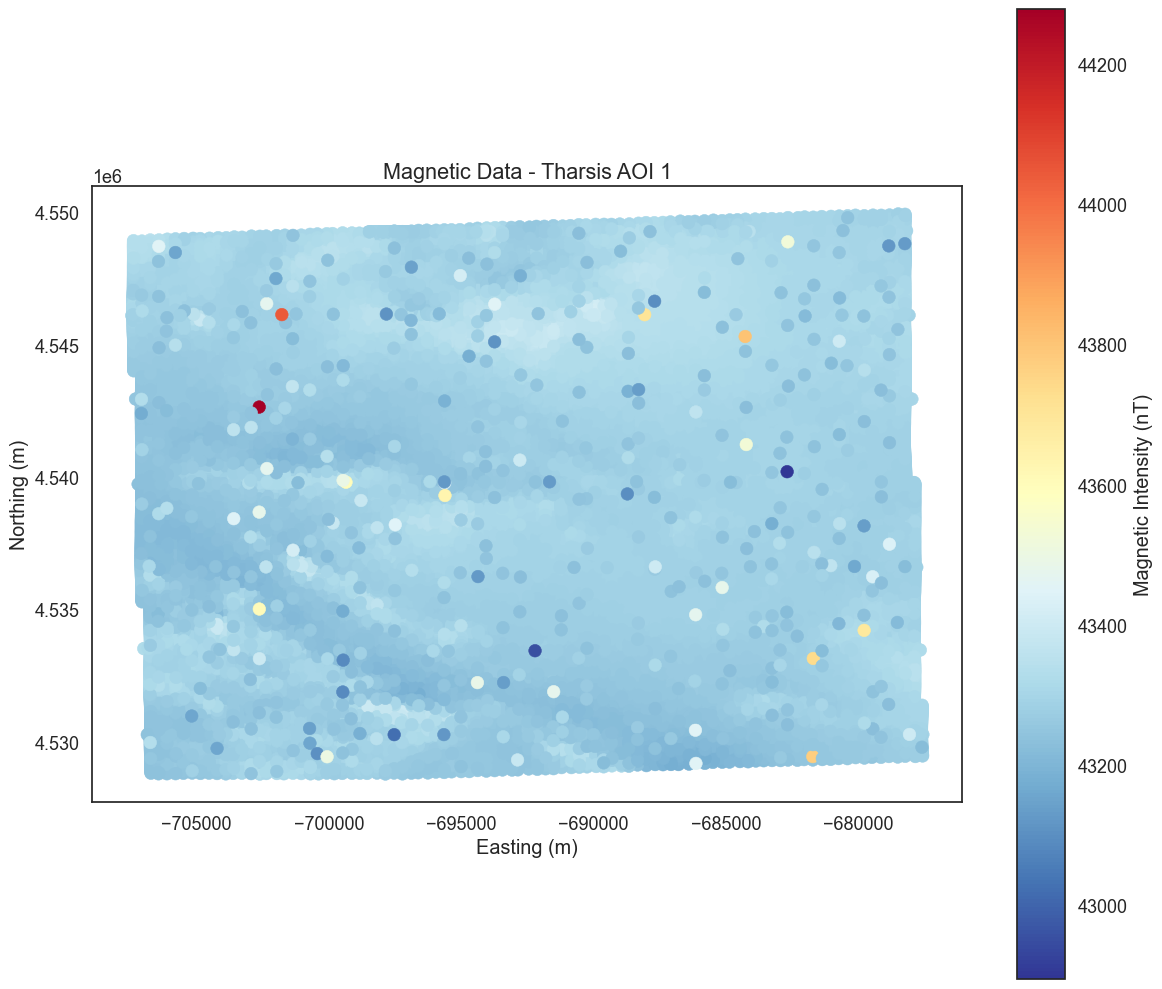

Magnetic data loaded successfully!
Data shape: (54261, 18)
Columns: ['ID', 'IDTR', 'VUELO', 'LINEA', 'XLON', 'YLAT', 'MAG', 'POT', 'THO', 'URA', 'TOT', 'RAD', 'BAR', 'GPS', 'FECHA', 'geometry', 'VALU_COORX', 'VALU_COORY']
Magnetic range: 42894.50 to 44278.60 nT


In [77]:
# Load and plot the geophysical gravity data and convert to right coordinate system
magnetic_data = gpd.read_file(r"C:\Users\mrcon\PycharmProjects\Mineye-Terranigma-1\Data\Tharsis AOI 1\AOI1_airborneMagnetics_EPSG23030.geojson")
magnetic_data = magnetic_data.to_crs(epsg=3857)

magnetic_data['VALU_COORX'] = magnetic_data.geometry.x
magnetic_data['VALU_COORY'] = magnetic_data.geometry.y

# Clip data to model bounds
magnetic_data = magnetic_data.cx[min_x:max_x, min_y:max_y]

# Create a plot of the magnetic data
fig, ax = plt.subplots(figsize=(12, 10))


# Plot the gravity data with a colormap
magnetic_plot = magnetic_data.plot(
    column='MAG', 
    ax=ax, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Magnetic Intensity (nT)', 'orientation': 'vertical'}
)

ax.set_title('Magnetic Data - Tharsis AOI 1')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Magnetic data loaded successfully!")
print(f"Data shape: {magnetic_data.shape}")
print(f"Columns: {magnetic_data.columns.tolist()}")
print(f"Magnetic range: {magnetic_data['MAG'].min():.2f} to {magnetic_data['MAG'].max():.2f} nT")

# 15. Filtering and Sampling Geophysical Data

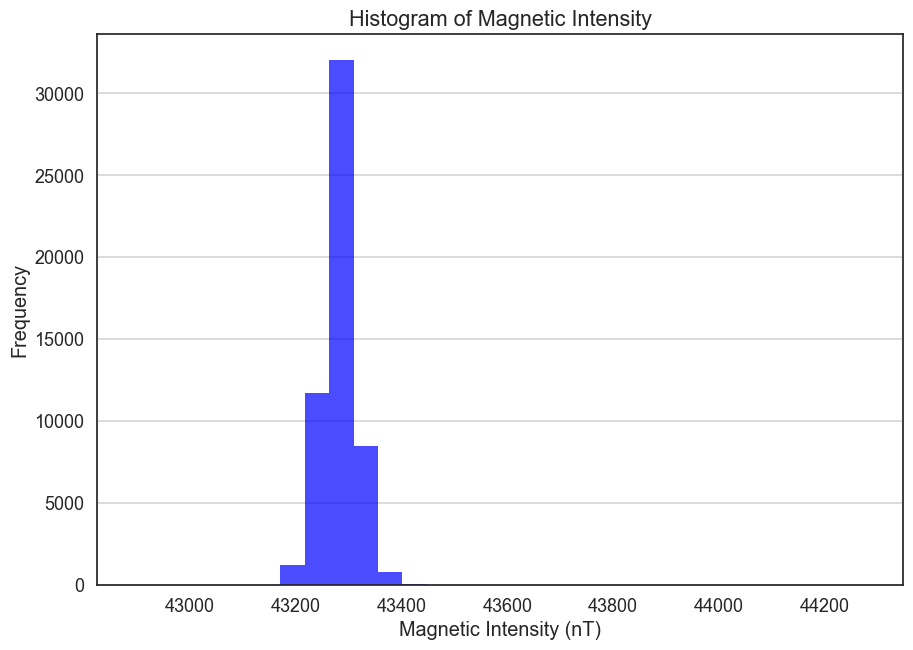

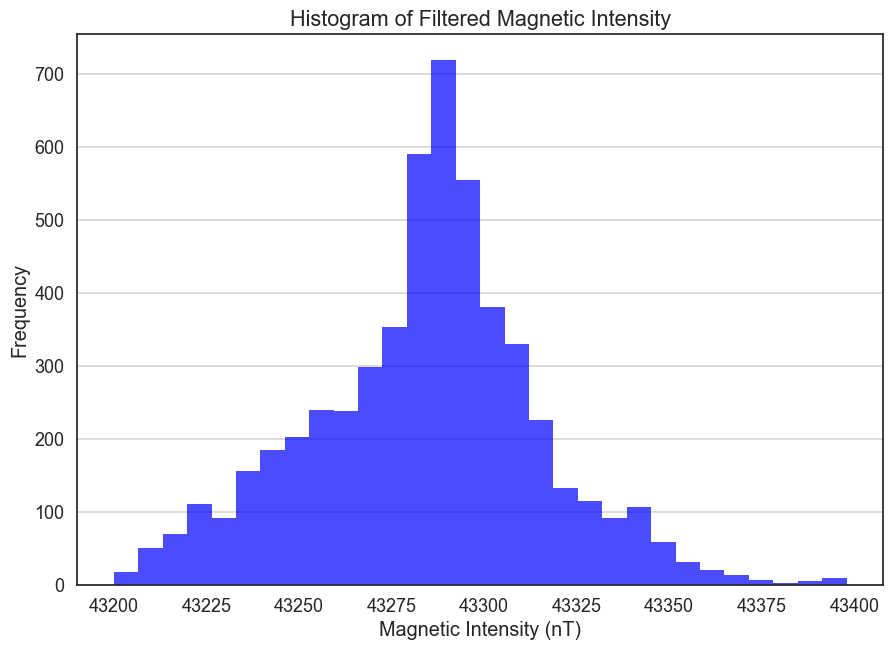

In [56]:
plt.hist(magnetic_data['MAG'], bins=30, color='blue', alpha=0.7)
plt.title('Histogram of Magnetic Intensity')
plt.xlabel('Magnetic Intensity (nT)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# remove outliers below 43200 and 43400
# Sample the magnetic data (e.g., every 10th point)
sampled_magnetic = magnetic_data.iloc[::10].copy()

filtered_magnetic = sampled_magnetic[
    (sampled_magnetic['MAG'] >= 43200) &
    (sampled_magnetic['MAG'] <= 43400)
].copy()

plt.hist(filtered_magnetic['MAG'], bins=30, color='blue', alpha=0.7)
plt.title('Histogram of Filtered Magnetic Intensity')
plt.xlabel('Magnetic Intensity (nT)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

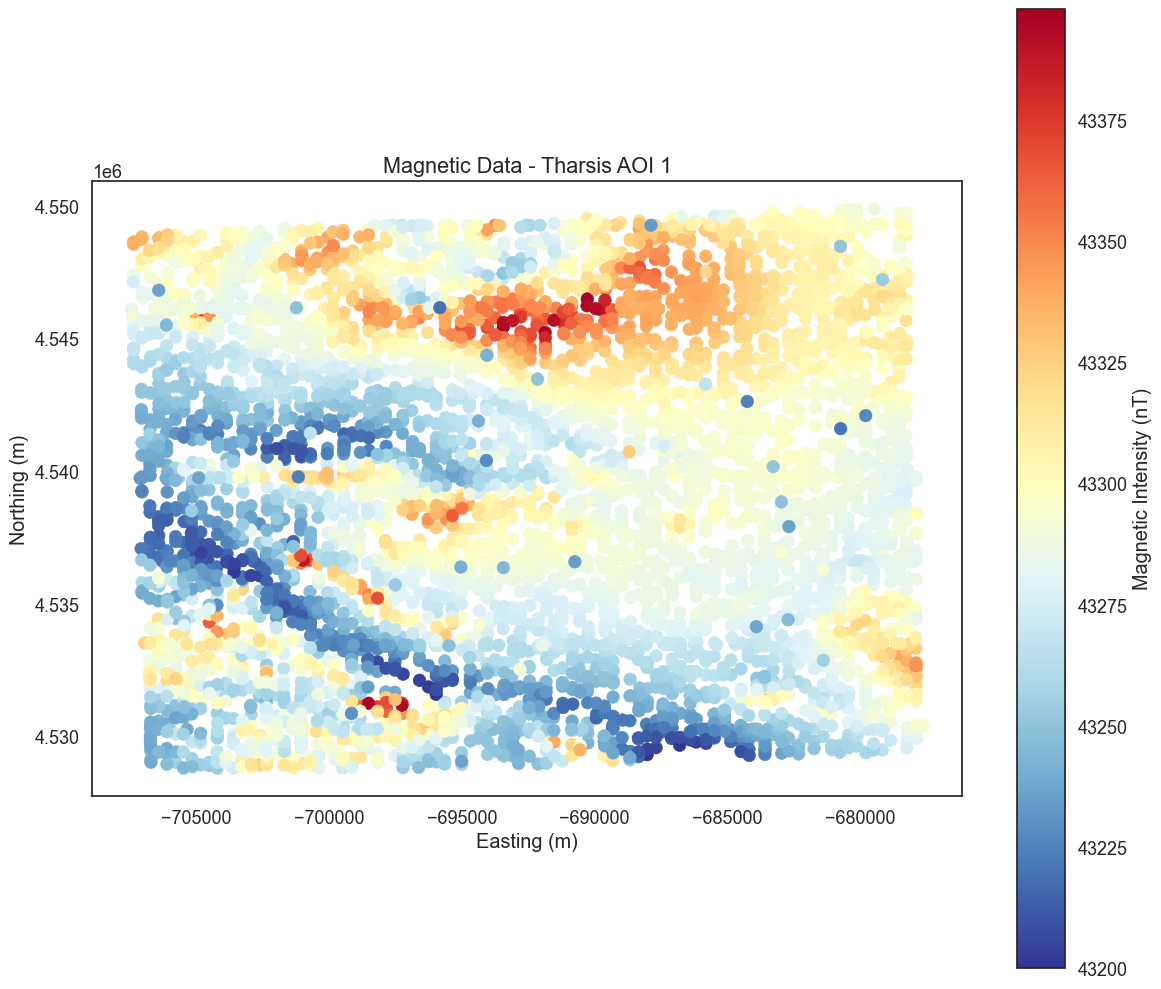

Magnetic data loaded successfully!
Data shape: (5404, 18)
Columns: ['ID', 'IDTR', 'VUELO', 'LINEA', 'XLON', 'YLAT', 'MAG', 'POT', 'THO', 'URA', 'TOT', 'RAD', 'BAR', 'GPS', 'FECHA', 'geometry', 'VALU_COORX', 'VALU_COORY']
Magnetic range: 43200.00 to 43397.90 nT


In [57]:
# Create a plot of the gravity data
fig, ax = plt.subplots(figsize=(12, 10))


# Plot the gravity data with a colormap
filtered_magnetic_plot = filtered_magnetic.plot(
    column='MAG', 
    ax=ax, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Magnetic Intensity (nT)', 'orientation': 'vertical'}
)

ax.set_title('Magnetic Data - Tharsis AOI 1')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Magnetic data loaded successfully!")
print(f"Data shape: {filtered_magnetic.shape}")
print(f"Columns: {filtered_magnetic.columns.tolist()}")
print(f"Magnetic range: {filtered_magnetic['MAG'].min():.2f} to {filtered_magnetic['MAG'].max():.2f} nT")

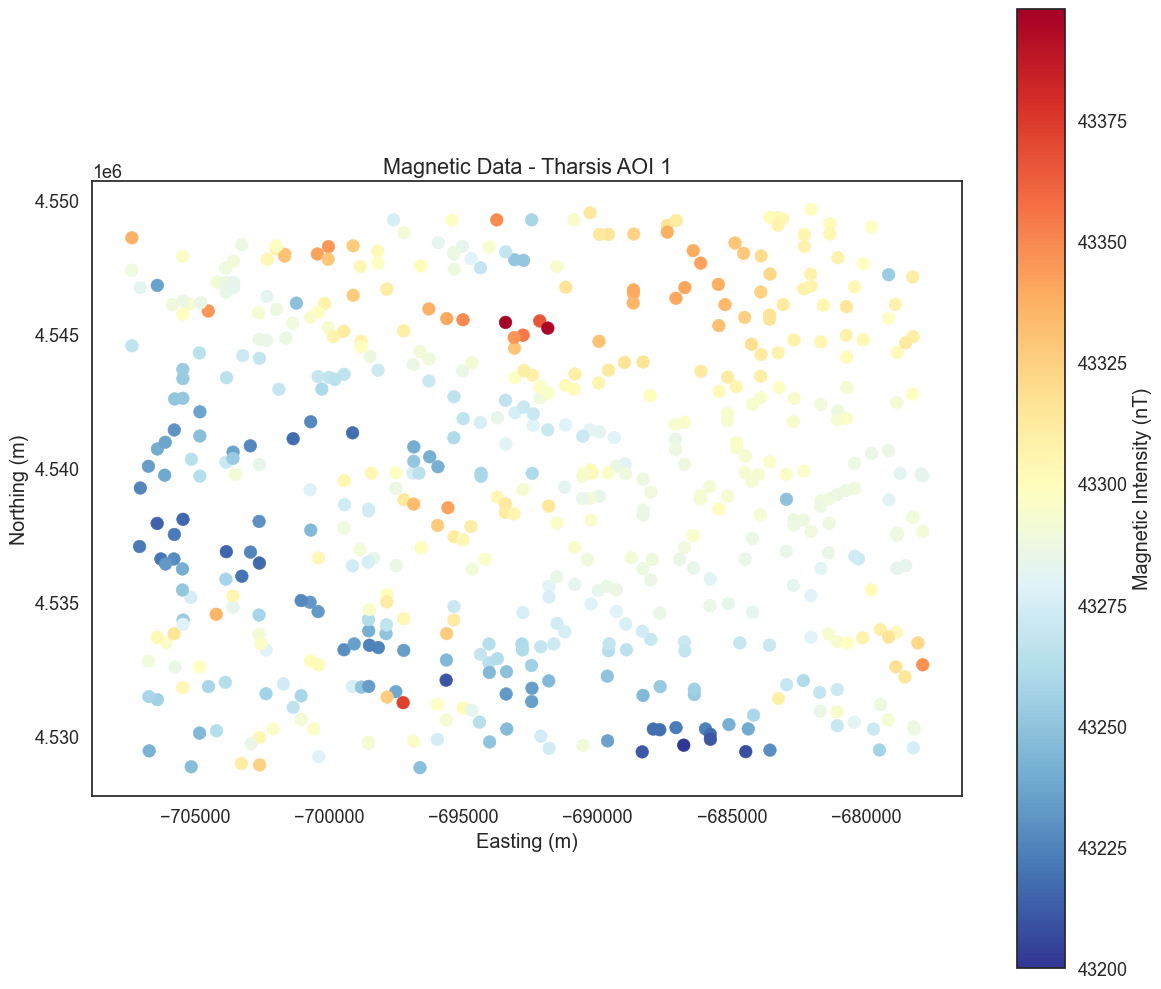

Magnetic data loaded successfully!
Data shape: (541, 18)
Columns: ['ID', 'IDTR', 'VUELO', 'LINEA', 'XLON', 'YLAT', 'MAG', 'POT', 'THO', 'URA', 'TOT', 'RAD', 'BAR', 'GPS', 'FECHA', 'geometry', 'VALU_COORX', 'VALU_COORY']
Magnetic range: 43200.00 to 43397.90 nT


In [58]:
# sample the magnetic data
filtered_magnetic_sampled = filtered_magnetic[::10]

# Create a plot of the gravity data
fig, ax = plt.subplots(figsize=(12, 10))


# Plot the gravity data with a colormap
filtered_magnetic_sampled_plot = filtered_magnetic_sampled.plot(
    column='MAG', 
    ax=ax, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Magnetic Intensity (nT)', 'orientation': 'vertical'}
)

ax.set_title('Magnetic Data - Tharsis AOI 1')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Magnetic data loaded successfully!")
print(f"Data shape: {filtered_magnetic_sampled.shape}")
print(f"Columns: {filtered_magnetic_sampled.columns.tolist()}")
print(f"Magnetic range: {filtered_magnetic_sampled['MAG'].min():.2f} to {filtered_magnetic_sampled['MAG'].max():.2f} nT")

# Creating Voxels

In [59]:
# Setting up model
geo_model = gp.create_geomodel(
    project_name='AOI',
    extent=[min_x, max_x, max_y, min_y, model_depth, max_z],
    refinement=6,
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=os.path.join(BASE_DIR, "temp_orientations.csv"),
        path_to_surface_points=os.path.join(BASE_DIR, "temp_points.csv"),
    )
)


# Set topography from processed file
path_to_topography_reduced = r'C:\Users\mrcon\PycharmProjects\Mineye-Terranigma-1\Data\Tharsis AOI 1\topo_reduced_sf0.1.tif'
gp.set_topography_from_file(grid=geo_model.grid, filepath=path_to_topography_reduced)

# Compute the geological model
gempy_model = gp.compute_model(geo_model)


Active grids: GridTypes.NONE|TOPOGRAPHY|OCTREE
Setting Backend To: AvailableBackends.numpy


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 9 chunks
Chunking done: 8 chunks


In [60]:
geo_model.grid # 64 x 64 x 64 voxels regular grid

Grid(values=array([[-7.07287594e+05,  4.54977908e+06, -4.93304688e+02],
       [-7.07287594e+05,  4.54977908e+06, -4.79914062e+02],
       [-7.07287594e+05,  4.54977908e+06, -4.66523438e+02],
       ...,
       [-6.67886956e+05,  4.55774667e+06,  1.00000000e+00],
       [-6.67886956e+05,  4.55807868e+06,  1.00000000e+00],
       [-6.67886956e+05,  4.55841069e+06,  1.00000000e+00]]), length=array([], dtype=float64), _octree_grid=RegularGrid(resolution=array([64, 64, 64]), extent=array([-7.075220e+05, -6.775180e+05,  4.549947e+06,  4.528453e+06,
       -5.000000e+02,  3.570000e+02]), values=array([[-7.07287594e+05,  4.54977908e+06, -4.93304688e+02],
       [-7.07287594e+05,  4.54977908e+06, -4.79914062e+02],
       [-7.07287594e+05,  4.54977908e+06, -4.66523438e+02],
       ...,
       [-6.77752406e+05,  4.52862092e+06,  3.23523438e+02],
       [-6.77752406e+05,  4.52862092e+06,  3.36914062e+02],
       [-6.77752406e+05,  4.52862092e+06,  3.50304688e+02]]), mask_topo=array([], shape=(0, 

In [61]:
# lithology in every voxel
lith_block = geo_model.solutions.raw_arrays.lith_block
lith_block_reshaped = lith_block.reshape(64,64,64)

# coordinate of every voxel
voxel_coords = geo_model.grid.regular_grid.values
voxel_coords_reshaped = voxel_coords.reshape(64, 64, 64, 3)
voxel_coords_reshaped[:,:,-1,:2].reshape(64*64,2);

# Assigning geophysical data to voxels

In [65]:
from scipy.spatial import cKDTree

# Assign every voxel coordinate to the closest gravity data point using a KD Tree
# Get surface voxel coordinates (top layer)
surface_voxel_coords = voxel_coords_reshaped[:,:,-1,:2].reshape(64*64, 2)

# Get gravity data coordinates
gravity_coords = gravity_data[['VALU_COORX', 'VALU_COORY']].values

# Build KD Tree for gravity data points
gravity_tree = cKDTree(gravity_coords)

# Find closest gravity point for each surface voxel
distances, indices = gravity_tree.query(surface_voxel_coords)

# Assign gravity values to surface voxels
voxel_gravity_values = gravity_data['VALU_BOU267'].iloc[indices].values

In [81]:
# Assign every voxel coordinate to the closest magnetic data point using a KD Tree
# Get surface voxel coordinates (top layer)
surface_voxel_coords = voxel_coords_reshaped[:,:,-1,:2].reshape(64*64, 2)

# Get magnetic data coordinates
magnetic_coords = filtered_magnetic[['VALU_COORX','VALU_COORY']].values

# Build KD Tree for magnetic data points
magnetic_tree = cKDTree(magnetic_coords)

# Find closest magnetic point for each surface voxel
distances, indices = magnetic_tree.query(surface_voxel_coords)

# Assign magnetic values to surface voxels
voxel_magnetic_values = filtered_magnetic['MAG'].iloc[indices].values

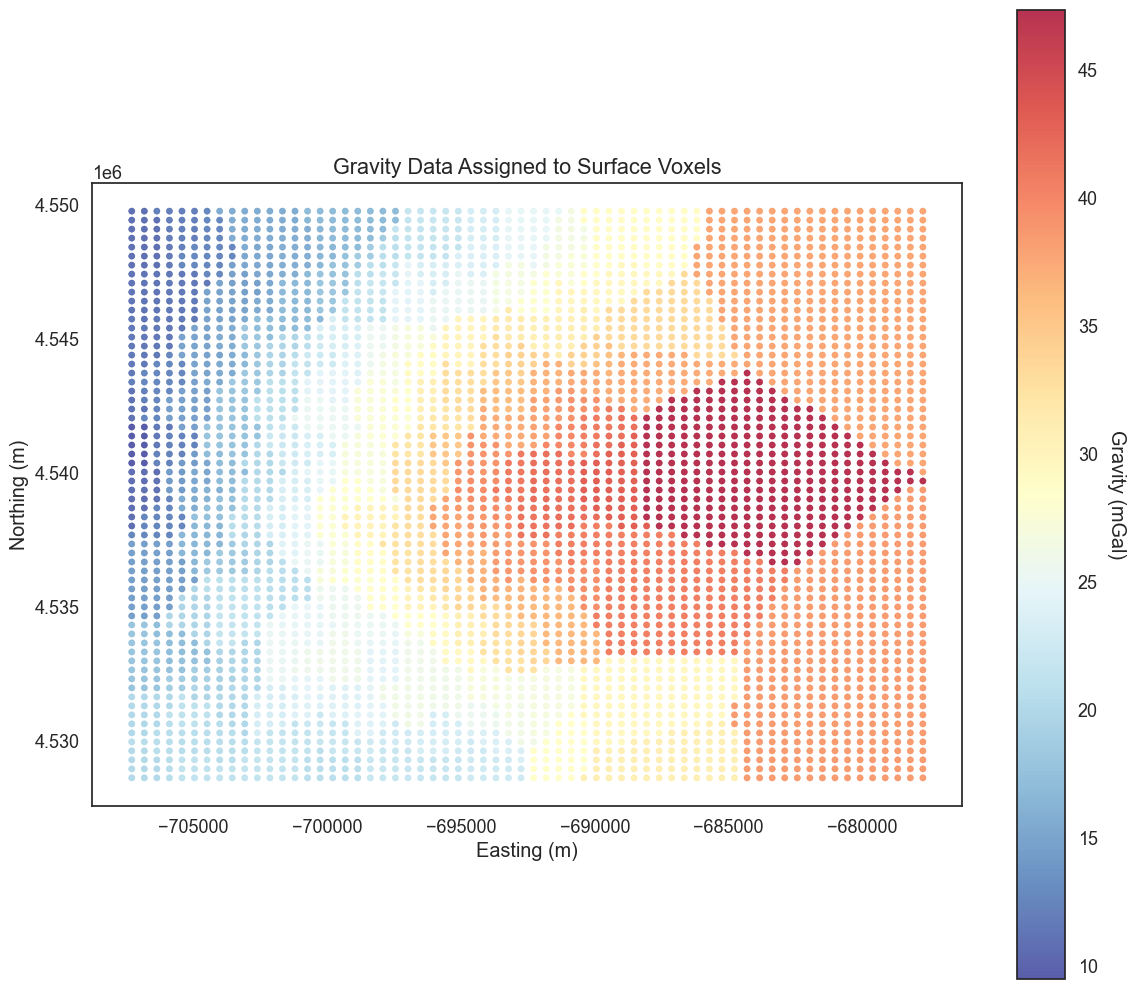

Gravity values assigned to 4096 surface voxels
Gravity range in voxels: 9.51 to 47.32 mGal


In [66]:
# Create a scatter plot showing gravity values assigned to surface voxels
fig, ax = plt.subplots(figsize=(12, 10))

# Create scatter plot with gravity values as colors
scatter = ax.scatter(x_voxel, y_voxel, c=voxel_gravity_values, 
                    cmap='RdYlBu_r', s=20, alpha=0.8)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Gravity (mGal)', rotation=270, labelpad=20)

# Set labels and title
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title('Gravity Data Assigned to Surface Voxels')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Gravity values assigned to {len(voxel_gravity_values)} surface voxels")
print(f"Gravity range in voxels: {voxel_gravity_values.min():.2f} to {voxel_gravity_values.max():.2f} mGal")

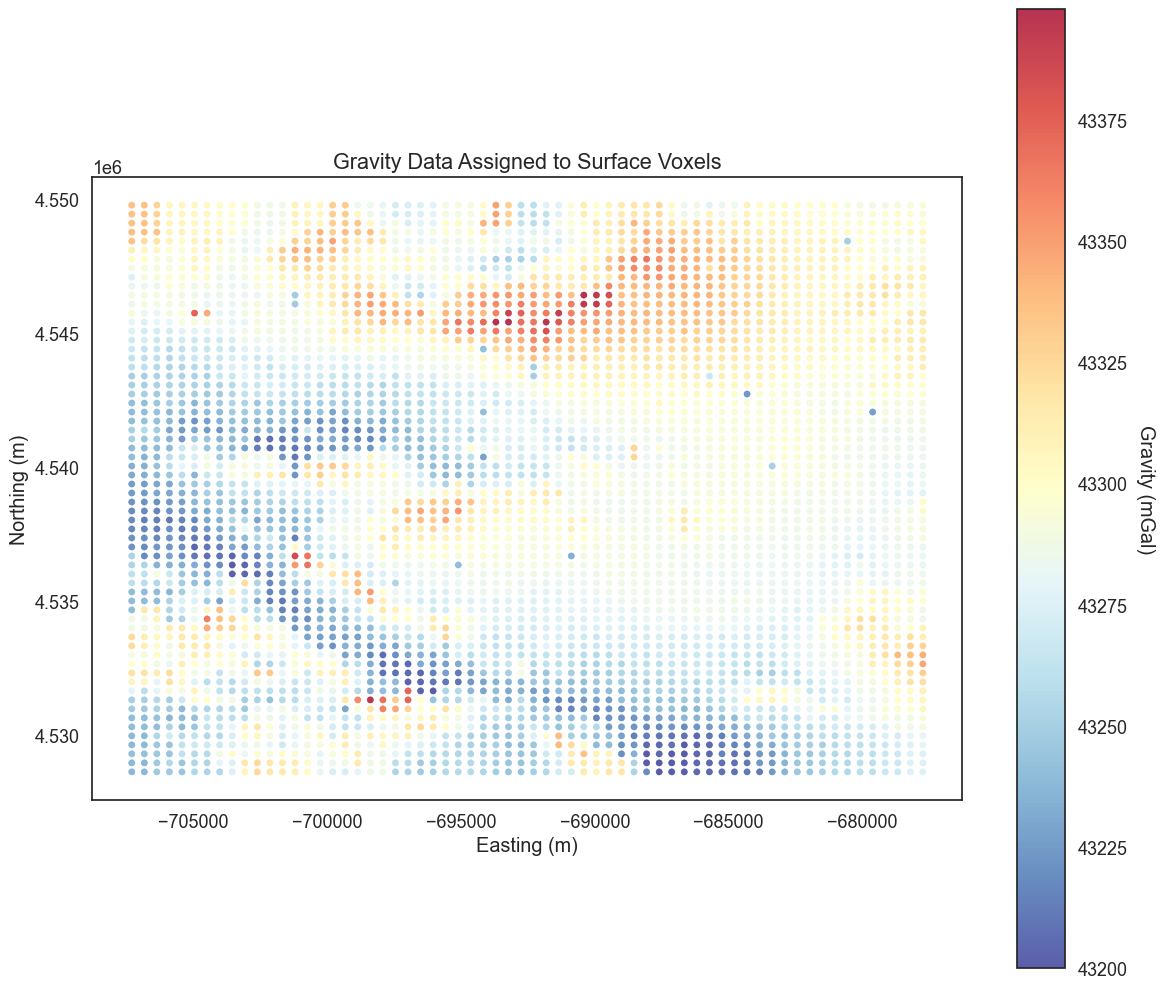

Gravity values assigned to 4096 surface voxels
Gravity range in voxels: 43200.00 to 43397.90 mGal


In [82]:
# Create a scatter plot showing gravity values assigned to surface voxels
fig, ax = plt.subplots(figsize=(12, 10))

# Create scatter plot with gravity values as colors
scatter = ax.scatter(x_voxel, y_voxel, c=voxel_magnetic_values, 
                    cmap='RdYlBu_r', s=20, alpha=0.8)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Gravity (mGal)', rotation=270, labelpad=20)

# Set labels and title
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title('Gravity Data Assigned to Surface Voxels')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Gravity values assigned to {len(voxel_magnetic_values)} surface voxels")
print(f"Gravity range in voxels: {voxel_magnetic_values.min():.2f} to {voxel_magnetic_values.max():.2f} mGal")

Unique lithologies in model: [1 2 3 4]
Random density assignments: {1: 2.3745401188473627, 2: 2.950714306409916, 3: 2.731993941811405, 4: 2.5986584841970366}
RMS gravity misfit: 11.25 mGal
Observed gravity range: 9.51 to 47.32 mGal
Predicted gravity range: 23.75 to 29.51 mGal


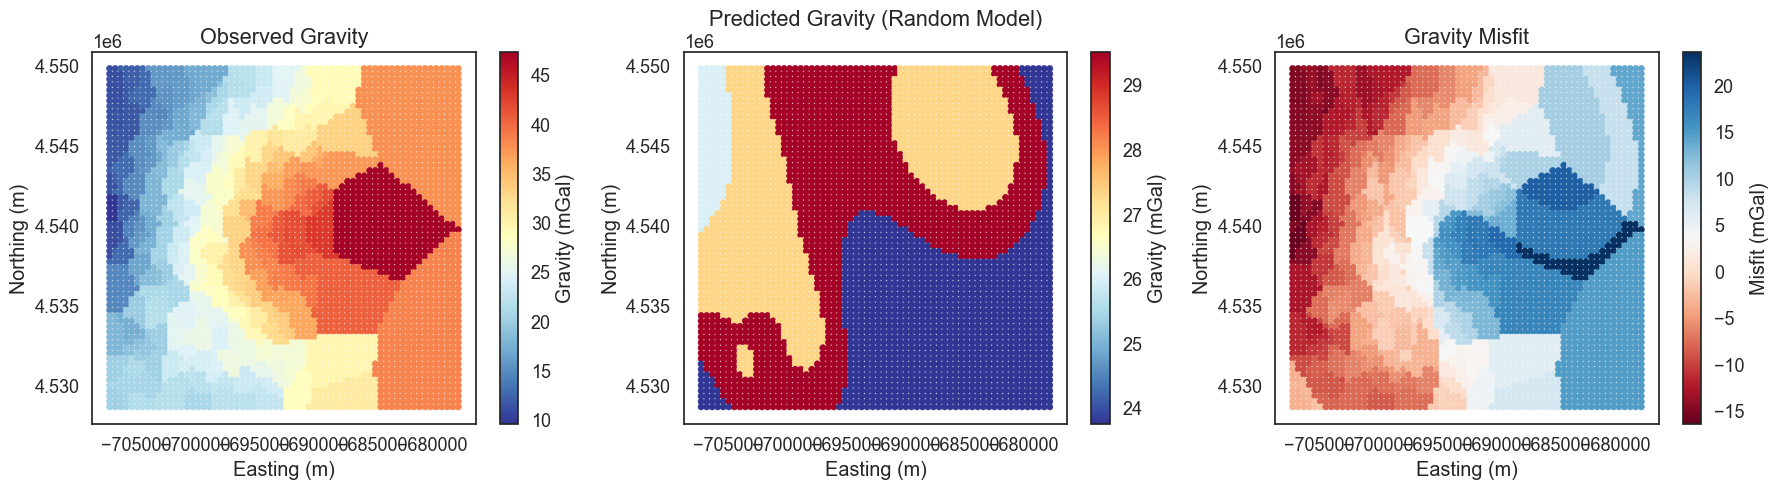

In [83]:
# Create a simple random model to test gravity inversion
# Start with random density values for each lithology type

# Get unique lithology values
unique_lithologies = np.unique(lith_block)
print(f"Unique lithologies in model: {unique_lithologies}")

# Create random density assignments for each lithology (typical rock densities 2.0-3.0 g/cm³)
np.random.seed(42)  # For reproducibility
density_map = {}
for lith in unique_lithologies:
    density_map[lith] = np.random.uniform(2.0, 3.0)

print(f"Random density assignments: {density_map}")

# Assign densities to all voxels based on their lithology
voxel_densities = np.array([density_map[lith] for lith in lith_block])
voxel_densities_reshaped = voxel_densities.reshape(64, 64, 64)

# For simplicity, we'll use surface voxel densities to predict gravity
surface_voxel_densities = voxel_densities_reshaped[:, :, -1].flatten()

# Simple gravity prediction (this is a very simplified forward model)
# Real gravity inversion would require proper physics calculations
predicted_gravity = surface_voxel_densities * 10  # Simplified scaling

# Calculate misfit between observed and predicted gravity
gravity_misfit = voxel_gravity_values - predicted_gravity
rms_misfit = np.sqrt(np.mean(gravity_misfit**2))

print(f"RMS gravity misfit: {rms_misfit:.2f} mGal")
print(f"Observed gravity range: {voxel_gravity_values.min():.2f} to {voxel_gravity_values.max():.2f} mGal")
print(f"Predicted gravity range: {predicted_gravity.min():.2f} to {predicted_gravity.max():.2f} mGal")

# Plot comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Observed gravity
im1 = ax1.scatter(x_voxel, y_voxel, c=voxel_gravity_values, cmap='RdYlBu_r', s=20)
ax1.set_title('Observed Gravity')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
plt.colorbar(im1, ax=ax1, label='Gravity (mGal)')

# Predicted gravity
im2 = ax2.scatter(x_voxel, y_voxel, c=predicted_gravity, cmap='RdYlBu_r', s=20)
ax2.set_title('Predicted Gravity (Random Model)')
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
plt.colorbar(im2, ax=ax2, label='Gravity (mGal)')

# Misfit
im3 = ax3.scatter(x_voxel, y_voxel, c=gravity_misfit, cmap='RdBu', s=20)
ax3.set_title('Gravity Misfit')
ax3.set_xlabel('Easting (m)')
ax3.set_ylabel('Northing (m)')
plt.colorbar(im3, ax=ax3, label='Misfit (mGal)')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.optimize import minimize

def gravity_forward_model(densities, lithology_block, surface_indices, surface_unique_lithologies):
    """Simple forward gravity model"""
    surface_lith_codes = lithology_block[surface_indices]
    # Map lithology codes to indices in surface_unique_lithologies
    lith_to_idx = {lith: i for i, lith in enumerate(surface_unique_lithologies)}
    idxs = np.array([lith_to_idx[code] for code in surface_lith_codes])
    surface_densities = densities[idxs]
    return surface_densities * 10  # Simplified scaling factor

def objective_function(densities, lithology_block, surface_indices, observed_gravity, surface_unique_lithologies):
    """Objective function to minimize - RMS misfit"""
    predicted_gravity = gravity_forward_model(densities, lithology_block, surface_indices, surface_unique_lithologies)
    misfit = observed_gravity - predicted_gravity
    return np.sqrt(np.mean(misfit**2))


# Get surface voxel indices (top layer of the 3D grid)
surface_indices = np.arange(len(surface_voxel_coords))
surface_lithologies = lith_block_reshaped[:, :, -1].flatten()

# Define observed gravity data
observed_gravity = voxel_gravity_values

# Get unique lithologies present in surface layer
surface_unique_lithologies = np.unique(surface_lithologies)
print(f"Unique lithologies in surface: {surface_unique_lithologies}")

# Use surface lithologies for the optimization (since we're only inverting surface data)
initial_densities = np.array([density_map[lith] for lith in surface_unique_lithologies])

# Bounds for density values (typical rock densities: 1.5 - 4.0 g/cm³)
density_bounds = [(1.5, 4.0) for _ in range(len(surface_unique_lithologies))]

print("Starting gravity inversion...")

# Perform the optimization
result = minimize(
    objective_function, 
    initial_densities, 
    args=(lith_block, surface_indices, observed_gravity, surface_unique_lithologies),
    bounds=density_bounds,
    method='L-BFGS-B',
    options={'maxiter': 100}
)

# Print optimization results
# Update density map with optimized values
optimized_density_map = {}
for i, lith in enumerate(surface_unique_lithologies):
    optimized_density_map[lith] = result.x[i]

# For lithologies not in surface, keep original values
for lith in unique_lithologies:
    if lith not in optimized_density_map:
        optimized_density_map[lith] = density_map[lith]

print(f"Optimized density assignments: {optimized_density_map}")

# Calculate improved gravity prediction
optimized_voxel_densities = np.array([optimized_density_map[lith] for lith in lith_block])
optimized_surface_densities = optimized_voxel_densities[surface_indices]
optimized_predicted_gravity = optimized_surface_densities * 10

# Calculate improved misfit
optimized_gravity_misfit = observed_gravity - optimized_predicted_gravity
optimized_rms_misfit = np.sqrt(np.mean(optimized_gravity_misfit**2))

print(f"Improved RMS gravity misfit: {optimized_rms_misfit:.2f} mGal")

Unique lithologies in surface: [1 2 3 4]
Starting gravity inversion...
Optimized density assignments: {1: 3.945151216979959, 2: 3.9449579039804754, 3: 3.437333681977239, 4: 2.1950231812517065}
Improved RMS gravity misfit: 5.84 mGal


In [115]:
from scipy.optimize import differential_evolution

# Use differential evolution (global optimizer)
bounds = density_bounds  # already defined as [(1.5, 4.0), ...]
print("Starting global gravity inversion (differential evolution)...")

result_global = differential_evolution(
    func=lambda densities: objective_function(
        densities, lith_block, surface_indices, observed_gravity, surface_unique_lithologies
    ),
    bounds=bounds,
    maxiter=1000,  # increase for more thorough search
    polish=True,
    disp=True
)

# Update density map with global optimized values
optimized_density_map_global = {}
for i, lith in enumerate(surface_unique_lithologies):
    optimized_density_map_global[lith] = result_global.x[i]
for lith in unique_lithologies:
    if lith not in optimized_density_map_global:
        optimized_density_map_global[lith] = density_map[lith]

print(f"Global optimized density assignments: {optimized_density_map_global}")

# Calculate improved gravity prediction
optimized_voxel_densities_global = np.array([optimized_density_map_global[lith] for lith in lith_block])
optimized_surface_densities_global = optimized_voxel_densities_global[surface_indices]
optimized_predicted_gravity_global = optimized_surface_densities_global * 10

# Calculate improved misfit
optimized_gravity_misfit_global = observed_gravity - optimized_predicted_gravity_global
optimized_rms_misfit_global = np.sqrt(np.mean(optimized_gravity_misfit_global**2))

print(f"Improved RMS gravity misfit (global):{optimized_rms_misfit_global}")

Starting global gravity inversion (differential evolution)...
differential_evolution step 1: f(x)= 6.251988672743869
differential_evolution step 2: f(x)= 6.251988672743869
differential_evolution step 3: f(x)= 5.96833919385549
differential_evolution step 4: f(x)= 5.947852056077636
differential_evolution step 5: f(x)= 5.928448519272769
differential_evolution step 6: f(x)= 5.9216363987112235
differential_evolution step 7: f(x)= 5.876516008479454
differential_evolution step 8: f(x)= 5.876516008479454
differential_evolution step 9: f(x)= 5.85037905986305
differential_evolution step 10: f(x)= 5.85037905986305
differential_evolution step 11: f(x)= 5.845642329058331
differential_evolution step 12: f(x)= 5.844058253031165
Polishing solution with 'L-BFGS-B'
Global optimized density assignments: {1: 3.945394098039711, 2: 3.944888110434475, 3: 3.4376792299043406, 4: 2.195040652886868}
Improved RMS gravity misfit (global):5.841400440702765


GRAVITY INVERSION OPTIMIZATION RESULTS

Original (Random) RMS Misfit: 11.25 mGal
Optimized RMS Misfit (Local): 5.84 mGal
Optimized RMS Misfit (Global): 5.84 mGal

Improvement (Local): 48.1%
Improvement (Global): 48.1%

Optimized Density Values (Global):
----------------------------------------
Lithology 1: 3.945 g/cm³
Lithology 2: 3.945 g/cm³
Lithology 3: 3.438 g/cm³
Lithology 4: 2.195 g/cm³


C:\Users\mrcon\AppData\Local\Temp\ipykernel_34808\3214402250.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


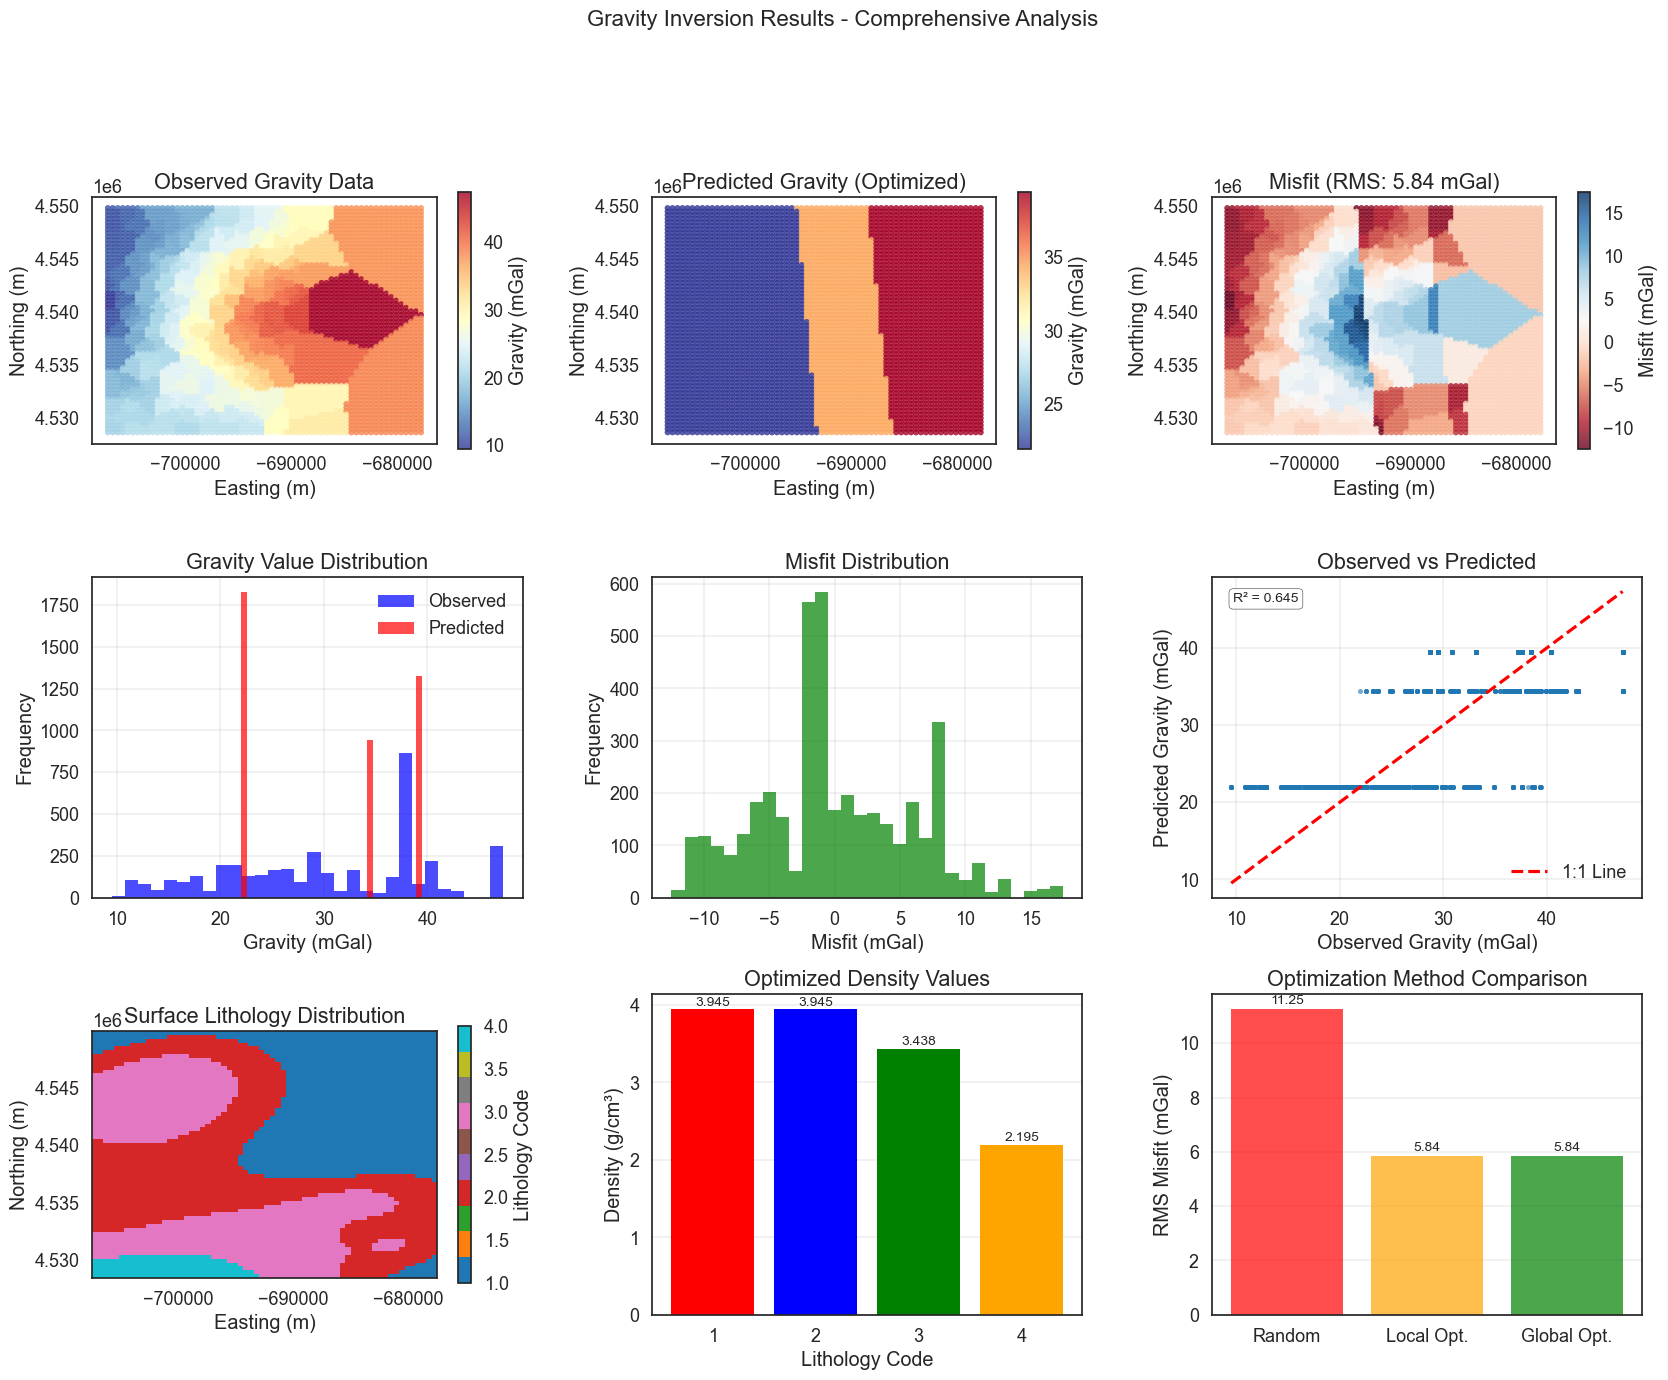


Detailed Statistics:
----------------------------------------
Correlation coefficient (R): 0.803
R-squared: 0.645
Mean absolute error: 4.66 mGal
Standard deviation of misfit: 5.84 mGal
Max absolute misfit: 17.45 mGal


In [116]:
# Print summary of optimization results
print("=" * 60)
print("GRAVITY INVERSION OPTIMIZATION RESULTS")
print("=" * 60)

print(f"\nOriginal (Random) RMS Misfit: {rms_misfit:.2f} mGal")
print(f"Optimized RMS Misfit (Local): {optimized_rms_misfit:.2f} mGal")
print(f"Optimized RMS Misfit (Global): {optimized_rms_misfit_global:.2f} mGal")

improvement_local = ((rms_misfit - optimized_rms_misfit) / rms_misfit * 100)
improvement_global = ((rms_misfit - optimized_rms_misfit_global) / rms_misfit * 100)

print(f"\nImprovement (Local): {improvement_local:.1f}%")
print(f"Improvement (Global): {improvement_global:.1f}%")

print(f"\nOptimized Density Values (Global):")
print("-" * 40)
for lith, density in optimized_density_map_global.items():
    print(f"Lithology {lith}: {density:.3f} g/cm³")

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 15))

# Create a 3x3 grid
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Row 1: Gravity data comparison
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.scatter(x_voxel, y_voxel, c=observed_gravity, cmap='RdYlBu_r', s=15, alpha=0.8)
ax1.set_title('Observed Gravity Data')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
ax1.set_aspect('equal')
plt.colorbar(im1, ax=ax1, label='Gravity (mGal)', shrink=0.8)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.scatter(x_voxel, y_voxel, c=optimized_predicted_gravity_global, cmap='RdYlBu_r', s=15, alpha=0.8)
ax2.set_title('Predicted Gravity (Optimized)')
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
ax2.set_aspect('equal')
plt.colorbar(im2, ax=ax2, label='Gravity (mGal)', shrink=0.8)

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.scatter(x_voxel, y_voxel, c=optimized_gravity_misfit_global, cmap='RdBu', s=15, alpha=0.8)
ax3.set_title(f'Misfit (RMS: {optimized_rms_misfit_global:.2f} mGal)')
ax3.set_xlabel('Easting (m)')
ax3.set_ylabel('Northing (m)')
ax3.set_aspect('equal')
plt.colorbar(im3, ax=ax3, label='Misfit (mGal)', shrink=0.8)

# Row 2: Histograms
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(observed_gravity, bins=30, alpha=0.7, color='blue', label='Observed')
ax4.hist(optimized_predicted_gravity_global, bins=30, alpha=0.7, color='red', label='Predicted')
ax4.set_xlabel('Gravity (mGal)')
ax4.set_ylabel('Frequency')
ax4.set_title('Gravity Value Distribution')
ax4.legend()
ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(optimized_gravity_misfit_global, bins=30, alpha=0.7, color='green')
ax5.set_xlabel('Misfit (mGal)')
ax5.set_ylabel('Frequency')
ax5.set_title('Misfit Distribution')
ax5.grid(alpha=0.3)

# Correlation plot
ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(observed_gravity, optimized_predicted_gravity_global, alpha=0.6, s=10)
# Add 1:1 line
min_val = min(observed_gravity.min(), optimized_predicted_gravity_global.min())
max_val = max(observed_gravity.max(), optimized_predicted_gravity_global.max())
ax6.plot([min_val, max_val], [min_val, max_val], 'r--', label='1:1 Line')
ax6.set_xlabel('Observed Gravity (mGal)')
ax6.set_ylabel('Predicted Gravity (mGal)')
ax6.set_title('Observed vs Predicted')
ax6.legend()
ax6.grid(alpha=0.3)

# Calculate correlation coefficient
correlation = np.corrcoef(observed_gravity, optimized_predicted_gravity_global)[0, 1]
ax6.text(0.05, 0.95, f'R² = {correlation**2:.3f}', transform=ax6.transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Row 3: Lithology and density visualization
ax7 = fig.add_subplot(gs[2, 0])
surface_lith_reshaped = surface_lithologies.reshape(64, 64)
im7 = ax7.imshow(surface_lith_reshaped, cmap='tab10', origin='lower', 
                extent=[min_x, max_x, min_y, max_y])
ax7.set_title('Surface Lithology Distribution')
ax7.set_xlabel('Easting (m)')
ax7.set_ylabel('Northing (m)')
cbar7 = plt.colorbar(im7, ax=ax7, shrink=0.8)
cbar7.set_label('Lithology Code')

# Density bar plot
ax8 = fig.add_subplot(gs[2, 1])
lithologies = list(optimized_density_map_global.keys())
densities = list(optimized_density_map_global.values())
bars = ax8.bar(lithologies, densities, color=['red', 'blue', 'green', 'orange'])
ax8.set_xlabel('Lithology Code')
ax8.set_ylabel('Density (g/cm³)')
ax8.set_title('Optimized Density Values')
ax8.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, density in zip(bars, densities):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{density:.3f}', ha='center', va='bottom')

# Convergence plot (if we had iteration history)
ax9 = fig.add_subplot(gs[2, 2])
misfit_comparison = [rms_misfit, optimized_rms_misfit, optimized_rms_misfit_global]
methods = ['Random', 'Local Opt.', 'Global Opt.']
colors = ['red', 'orange', 'green']
bars = ax9.bar(methods, misfit_comparison, color=colors, alpha=0.7)
ax9.set_ylabel('RMS Misfit (mGal)')
ax9.set_title('Optimization Method Comparison')
ax9.grid(axis='y', alpha=0.3)

# Add value labels
for bar, misfit in zip(bars, misfit_comparison):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{misfit:.2f}', ha='center', va='bottom')

plt.suptitle('Gravity Inversion Results - Comprehensive Analysis', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# Print additional statistics
print(f"\nDetailed Statistics:")
print("-" * 40)
print(f"Correlation coefficient (R): {correlation:.3f}")
print(f"R-squared: {correlation**2:.3f}")
print(f"Mean absolute error: {np.mean(np.abs(optimized_gravity_misfit_global)):.2f} mGal")
print(f"Standard deviation of misfit: {np.std(optimized_gravity_misfit_global):.2f} mGal")
print(f"Max absolute misfit: {np.max(np.abs(optimized_gravity_misfit_global)):.2f} mGal")

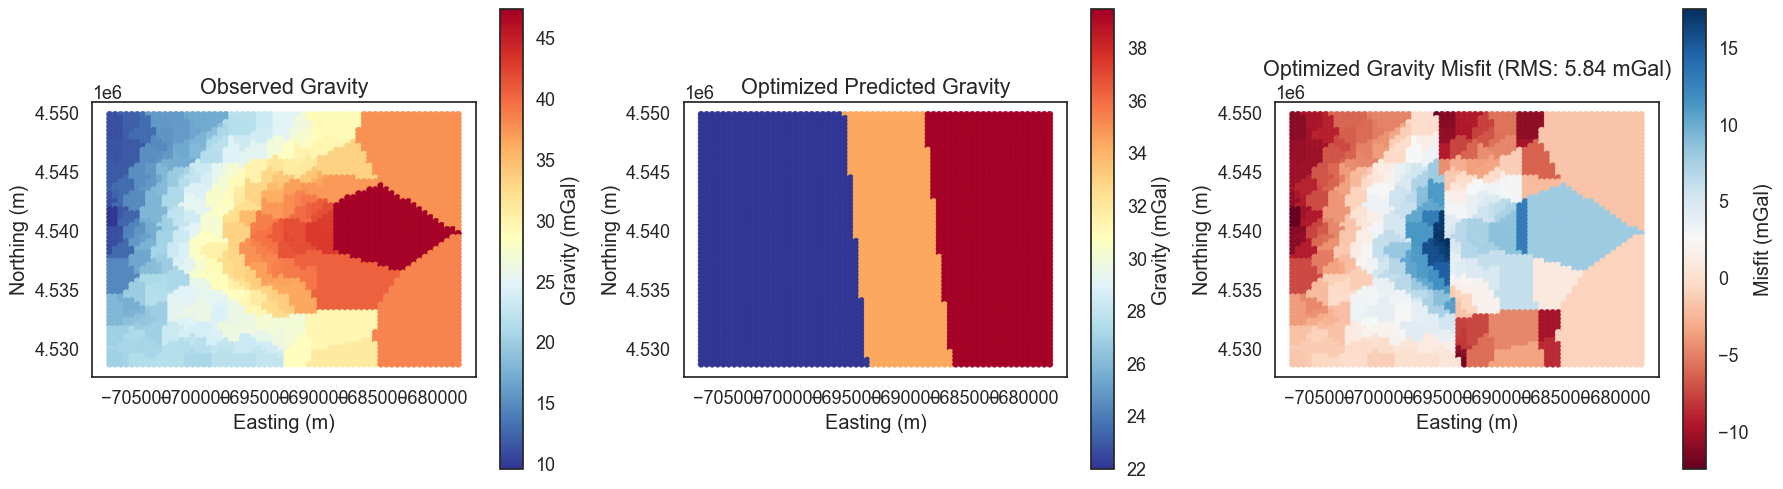

Optimization Results:
Original RMS misfit: 5.84 mGal
Optimized RMS misfit: 5.84 mGal
Improvement: 48.1%

Optimized density values:
Lithology 1: 3.945 g/cm³
Lithology 2: 3.945 g/cm³
Lithology 3: 3.437 g/cm³
Lithology 4: 2.195 g/cm³


In [112]:
# Plot comparison of original vs optimized gravity models
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Extract x and y coordinates for plotting
x_voxel = surface_voxel_coords[:, 0]
y_voxel = surface_voxel_coords[:, 1]

# Observed gravity
im1 = ax1.scatter(x_voxel, y_voxel, c=observed_gravity, cmap='RdYlBu_r', s=20)
ax1.set_title('Observed Gravity')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
ax1.set_aspect('equal')
plt.colorbar(im1, ax=ax1, label='Gravity (mGal)')

# Optimized predicted gravity
im2 = ax2.scatter(x_voxel, y_voxel, c=optimized_predicted_gravity_global, cmap='RdYlBu_r', s=20)
ax2.set_title('Optimized Predicted Gravity')
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
ax2.set_aspect('equal')
plt.colorbar(im2, ax=ax2, label='Gravity (mGal)')

# Optimized misfit
im3 = ax3.scatter(x_voxel, y_voxel, c=optimized_gravity_misfit_global, cmap='RdBu', s=20)
ax3.set_title(f'Optimized Gravity Misfit (RMS: {optimized_rms_misfit_global:.2f} mGal)')
ax3.set_xlabel('Easting (m)')
ax3.set_ylabel('Northing (m)')
ax3.set_aspect('equal')
plt.colorbar(im3, ax=ax3, label='Misfit (mGal)')

plt.tight_layout()
plt.show()

print("Optimization Results:")
print(f"Original RMS misfit: {optimized_rms_misfit_global:.2f} mGal")
print(f"Optimized RMS misfit: {optimized_rms_misfit_global:.2f} mGal")
print(f"Improvement: {((rms_misfit - optimized_rms_misfit_global) / rms_misfit * 100):.1f}%")
print(f"\nOptimized density values:")
for lith, density in optimized_density_map.items():
    print(f"Lithology {lith}: {density:.3f} g/cm³")

In [126]:
# Use all 3D voxels for inversion (not just surface)
# Assume measured gravity data is assigned to the top of each voxel column

# Flatten all voxel coordinates and lithologies
all_voxel_coords = voxel_coords.reshape(-1, 3)
all_lithologies = lith_block.flatten()

# Assign gravity data to the top of each voxel column (repeat measured gravity for each column)
# Here, we assume measured gravity is only available for the top layer, so we broadcast it down each column
# If you have measured gravity for all voxels, use that array directly
observed_gravity_3d = np.tile(voxel_gravity_values, 64)  # 64 layers deep

# Get unique lithologies in the whole model
all_unique_lithologies = np.unique(all_lithologies)
initial_densities_3d = np.array([density_map[lith] for lith in all_unique_lithologies])
density_bounds_3d = [(1.5, 4.0) for _ in range(len(all_unique_lithologies))]

def gravity_forward_model_3d(densities, lithology_block, unique_lithologies):
    """Forward gravity model for all voxels (simplified)"""
    lith_to_idx = {lith: i for i, lith in enumerate(unique_lithologies)}
    idxs = np.array([lith_to_idx[code] for code in lithology_block])
    voxel_densities = densities[idxs]
    return voxel_densities * 10  # Simplified scaling

def objective_function_3d(densities, lithology_block, observed_gravity, unique_lithologies):
    predicted_gravity = gravity_forward_model_3d(densities, lithology_block, unique_lithologies)
    misfit = observed_gravity - predicted_gravity
    return np.sqrt(np.mean(misfit**2))

print("Starting 3D gravity inversion (local)...")
result_3d = minimize(
    objective_function_3d,
    initial_densities_3d,
    args=(all_lithologies, observed_gravity_3d, all_unique_lithologies),
    bounds=density_bounds_3d,
    method='L-BFGS-B',
    options={'maxiter': 1000}
)

optimized_density_map_3d = {lith: result_3d.x[i] for i, lith in enumerate(all_unique_lithologies)}
print(f"Optimized 3D density assignments: {optimized_density_map_3d}")

# Global optimizer
print("Starting 3D gravity inversion (global)...")
result_global_3d = differential_evolution(
    func=lambda densities: objective_function_3d(densities, all_lithologies, observed_gravity_3d, all_unique_lithologies),
    bounds=density_bounds_3d,
    maxiter=1000,
    polish=True,
    disp=True
)
optimized_density_map_global_3d = {lith: result_global_3d.x[i] for i, lith in enumerate(all_unique_lithologies)}
print(f"Global optimized 3D density assignments: {optimized_density_map_global_3d}")

# Calculate improved gravity prediction for global optimizer
optimized_voxel_densities_global_3d = np.array([optimized_density_map_global_3d[lith] for lith in all_lithologies])
optimized_predicted_gravity_global_3d = optimized_voxel_densities_global_3d * 10
optimized_gravity_misfit_global_3d = observed_gravity_3d - optimized_predicted_gravity_global_3d
optimized_rms_misfit_global_3d = np.sqrt(np.mean(optimized_gravity_misfit_global_3d**2))

print(f"Improved RMS gravity misfit (global, 3D): {optimized_rms_misfit_global_3d:.2f} mGal")

Starting 3D gravity inversion (local)...
Optimized 3D density assignments: {1: 3.500188141685826, 2: 2.9065002028986675, 3: 2.5972968324051204, 4: 2.133525570714295}
Starting 3D gravity inversion (global)...
differential_evolution step 1: f(x)= 9.376319583014782
differential_evolution step 2: f(x)= 9.080249815227237
differential_evolution step 3: f(x)= 9.076569868357755
differential_evolution step 4: f(x)= 9.074173695550302
differential_evolution step 5: f(x)= 8.961212341785247
differential_evolution step 6: f(x)= 8.954457052023983
differential_evolution step 7: f(x)= 8.951656093409541
Polishing solution with 'L-BFGS-B'
Global optimized 3D density assignments: {1: 3.5001874645082514, 2: 2.906501355343002, 3: 2.597299875448069, 4: 2.1335289807101803}
Improved RMS gravity misfit (global, 3D): 8.95 mGal


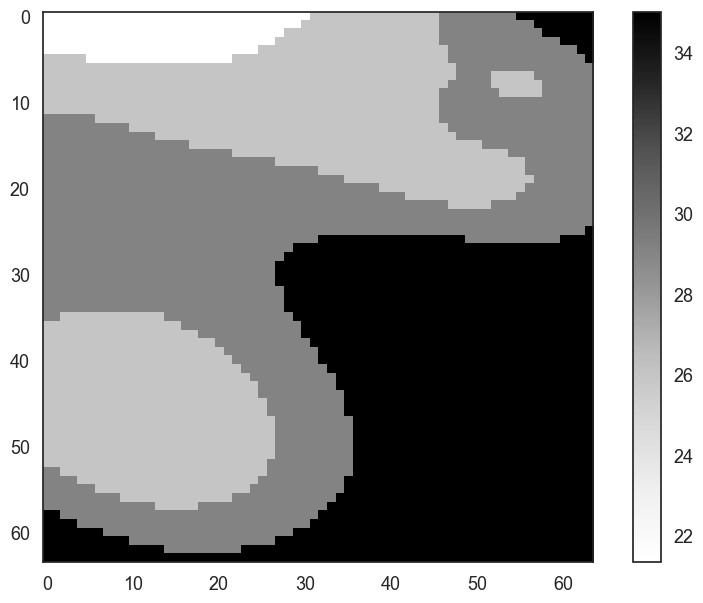

In [131]:
plt.imshow(optimized_predicted_gravity_global_3d.reshape(64,64,64)[:,:,-1])
plt.colorbar()

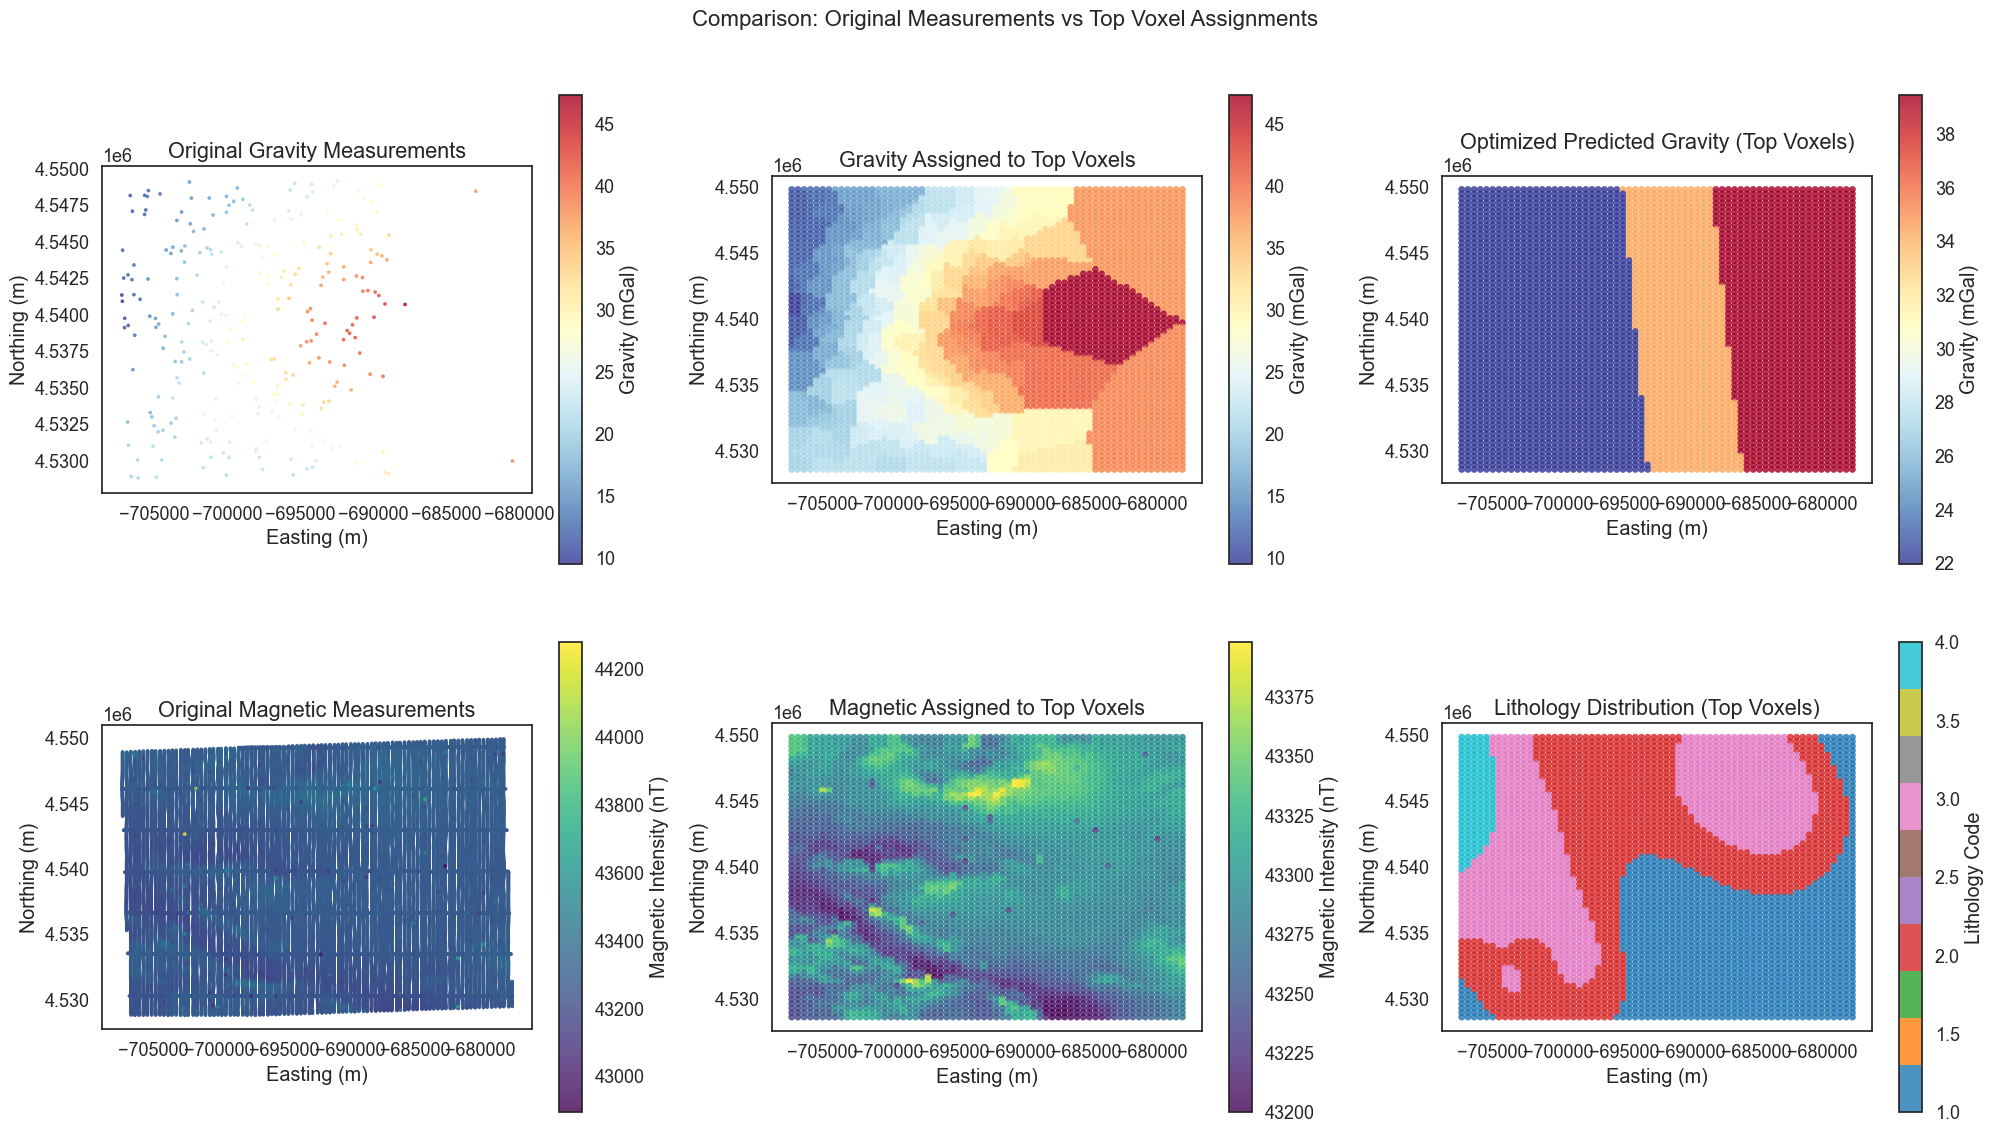

COMPARISON SUMMARY: ORIGINAL MEASUREMENTS vs TOP VOXEL ASSIGNMENTS

GRAVITY DATA:
Original measurements - Count: 260, Range: 9.51 to 47.32 mGal
Top voxel assignments - Count: 4096, Range: 9.51 to 47.32 mGal
Optimized predictions - Count: 4096, Range: 21.95 to 39.45 mGal

MAGNETIC DATA:
Original measurements - Count: 54261, Range: 42894.50 to 44278.60 nT
Top voxel assignments - Count: 4096, Range: 43200.00 to 43397.90 nT

TOP VOXEL GRID:
Grid dimensions: 64 x 64 = 4096 voxels
Spatial extent: X [-707522 to -677518], Y [4528453 to 4549947]
Unique lithologies in surface: [1 2 3 4]

OPTIMIZATION RESULTS:
RMS misfit: 5.84 mGal
Correlation (R²): 0.645


In [118]:
# Create a comprehensive comparison visualization of top voxels vs original measurements
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Row 1: Gravity data comparison
# Original gravity measurements
im1 = axes[0, 0].scatter(gravity_data['VALU_COORX'], gravity_data['VALU_COORY'], 
                        c=gravity_data['VALU_BOU267'], cmap='RdYlBu_r', s=5, alpha=0.8)
axes[0, 0].set_title('Original Gravity Measurements')
axes[0, 0].set_xlabel('Easting (m)')
axes[0, 0].set_ylabel('Northing (m)')
axes[0, 0].set_aspect('equal')
plt.colorbar(im1, ax=axes[0, 0], label='Gravity (mGal)', shrink=0.8)

# Gravity values assigned to top voxels
im2 = axes[0, 1].scatter(x_voxel, y_voxel, c=voxel_gravity_values, 
                        cmap='RdYlBu_r', s=20, alpha=0.8)
axes[0, 1].set_title('Gravity Assigned to Top Voxels')
axes[0, 1].set_xlabel('Easting (m)')
axes[0, 1].set_ylabel('Northing (m)')
axes[0, 1].set_aspect('equal')
plt.colorbar(im2, ax=axes[0, 1], label='Gravity (mGal)', shrink=0.8)

# Optimized predicted gravity for top voxels
im3 = axes[0, 2].scatter(x_voxel, y_voxel, c=optimized_predicted_gravity_global, 
                        cmap='RdYlBu_r', s=20, alpha=0.8)
axes[0, 2].set_title('Optimized Predicted Gravity (Top Voxels)')
axes[0, 2].set_xlabel('Easting (m)')
axes[0, 2].set_ylabel('Northing (m)')
axes[0, 2].set_aspect('equal')
plt.colorbar(im3, ax=axes[0, 2], label='Gravity (mGal)', shrink=0.8)

# Row 2: Magnetic data comparison
# Original magnetic measurements
im4 = axes[1, 0].scatter(magnetic_data['VALU_COORX'], magnetic_data['VALU_COORY'], 
                        c=magnetic_data['MAG'], cmap='viridis', s=5, alpha=0.8)
axes[1, 0].set_title('Original Magnetic Measurements')
axes[1, 0].set_xlabel('Easting (m)')
axes[1, 0].set_ylabel('Northing (m)')
axes[1, 0].set_aspect('equal')
plt.colorbar(im4, ax=axes[1, 0], label='Magnetic Intensity (nT)', shrink=0.8)

# Magnetic values assigned to top voxels
im5 = axes[1, 1].scatter(x_voxel, y_voxel, c=voxel_magnetic_values, 
                        cmap='viridis', s=20, alpha=0.8)
axes[1, 1].set_title('Magnetic Assigned to Top Voxels')
axes[1, 1].set_xlabel('Easting (m)')
axes[1, 1].set_ylabel('Northing (m)')
axes[1, 1].set_aspect('equal')
plt.colorbar(im5, ax=axes[1, 1], label='Magnetic Intensity (nT)', shrink=0.8)

# Lithology distribution in top voxels
im6 = axes[1, 2].scatter(x_voxel, y_voxel, c=surface_lithologies, 
                        cmap='tab10', s=20, alpha=0.8)
axes[1, 2].set_title('Lithology Distribution (Top Voxels)')
axes[1, 2].set_xlabel('Easting (m)')
axes[1, 2].set_ylabel('Northing (m)')
axes[1, 2].set_aspect('equal')
cbar6 = plt.colorbar(im6, ax=axes[1, 2], shrink=0.8)
cbar6.set_label('Lithology Code')

plt.suptitle('Comparison: Original Measurements vs Top Voxel Assignments', fontsize=16)
plt.tight_layout()
plt.show()

# Print summary statistics
print("=" * 80)
print("COMPARISON SUMMARY: ORIGINAL MEASUREMENTS vs TOP VOXEL ASSIGNMENTS")
print("=" * 80)

print(f"\nGRAVITY DATA:")
print(f"Original measurements - Count: {len(gravity_data)}, Range: {gravity_data['VALU_BOU267'].min():.2f} to {gravity_data['VALU_BOU267'].max():.2f} mGal")
print(f"Top voxel assignments - Count: {len(voxel_gravity_values)}, Range: {voxel_gravity_values.min():.2f} to {voxel_gravity_values.max():.2f} mGal")
print(f"Optimized predictions - Count: {len(optimized_predicted_gravity_global)}, Range: {optimized_predicted_gravity_global.min():.2f} to {optimized_predicted_gravity_global.max():.2f} mGal")

print(f"\nMAGNETIC DATA:")
print(f"Original measurements - Count: {len(magnetic_data)}, Range: {magnetic_data['MAG'].min():.2f} to {magnetic_data['MAG'].max():.2f} nT")
print(f"Top voxel assignments - Count: {len(voxel_magnetic_values)}, Range: {voxel_magnetic_values.min():.2f} to {voxel_magnetic_values.max():.2f} nT")

print(f"\nTOP VOXEL GRID:")
print(f"Grid dimensions: 64 x 64 = {len(surface_voxel_coords)} voxels")
print(f"Spatial extent: X [{min_x} to {max_x}], Y [{min_y} to {max_y}]")
print(f"Unique lithologies in surface: {np.unique(surface_lithologies)}")

print(f"\nOPTIMIZATION RESULTS:")
print(f"RMS misfit: {optimized_rms_misfit_global:.2f} mGal")
print(f"Correlation (R²): {correlation**2:.3f}")